# 实验目的
相同环境参数下，分别得到PE_PLST和FDTD在同一*x-z平面*内的电磁传播情况。将两者进行对比趋势变化、均方根差，验证PE_PLST算法正确性。

# 实验步骤
## 验证方案
抛物方程（Parabolic Equation, PE）方法自20世纪40年代由Leontovich和Fock提出，并在70年代由Tappert引入分步傅里叶变换（SSFT）求解后，已经成为解决大尺度、非均匀介质（如大气波导）中电磁波传播的**“黄金标准” (Gold Standard)**。因此不需要验证PE算法。
但是引入分段线性位移变换修正下边界，这是对原有模型的改进，需要验证是否引入了非物理的数值误差，遮挡效应计算是否准确。但是不需要进行物理实测验证，而是使用数值对标验证。
### 退化验证
将海浪高度设为0（退化为平坦海面）。验证分段线性变换在平坦情况下是否能完美还原为标准PE的解（或双射线模型解）。如果平海面都算不对，说明变换矩阵或相位修正项推导有误。
### 与精确解进行对比
使用FDTD仿真全波解，FDTD直接求解麦克斯韦方程组，包含所有散射、衍射和反射效应，被视为全波解（Full-wave solution）。

1. 构建一个小尺度的海面模型（例如几百米，因为FDTD算不动几十公里）。

2. 设置一个确定的分段线性海浪形状。

3. 分别用改进PE和FDTD计算传播因子（Propagation Factor）。

4. 画出两条曲线：如果两者在远场吻合良好，且你的PE比FDTD快几个数量级，那么你的改进就是成功的。

### 指标
a. 均方根误差 (RMSE) -- 核心指标
$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (L_{PE}(i) - L_{FDTD}(i))^2}$$
< 1 dB: 极好（Excellent），几乎完美复现全波解。

1 ~ 3 dB: 良好（Good），这是大多数改进型 PE 算法能达到的区间，完全可以接受。

\> 5 dB: 需要解释原因（例如只在深阴影区误差大，但在覆盖区很准）。


b. 平均偏差 (Mean Bias Error, MBE) —— 辅助指标
$$MBE = \frac{1}{N} \sum_{i=1}^{N} (L_{PE}(i) - L_{FDTD}(i))$$
意义：用于判断你的算法是否存在系统性误差。如果 MBE > 0，说明你的算法系统性地低估了损耗（过于乐观）。如果 MBE < 0，说明系统性地高估了损耗（过于保守）。理想情况下 MBE 应接近 0。

c. 最大绝对误差 (Max Absolute Error) —— 针对性指标
$$MaxError = \max |L_{PE}(i) - L_{FDTD}(i)|$$
意义：通常出现在干涉零点（Deep Nulls）。PE 方法在预测零点位置时通常会有轻微频移或位置偏移，导致该点误差巨大（例如 FDTD 是 -80dB，PE 是 -60dB）。如何辩解：如果最大误差只出现在极深的零点，你可以解释为“对于实际通信工程，低于接收机灵敏度（如 -110dBm）的深零点误差不影响连通性判断”。

# 方法延申
验证了方法正确性后，引入编队场景。用PE算出编队中N艘船的功率分布情况，生成一个图（Dynamic Graph）。聚焦于恶劣海况下编队构型的稳健性分析

# 代码实现
1. 生成JONSWAP海面
2. 得到观测海面高度（x-z平面）
3. 分别进行PE FDTD计算
4. 绘制对比图

In [ ]:
# 导入包
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import scipy.fft as fft
import pandas as pd
from abc import ABC, abstractmethod

# ==========================================
# 场景生成器 (Scene Generator)
# 定义全局物理参数、生成海面、统一下发坐标
# ==========================================
class SceneGenerator:
    def __init__(self, 
                 freq_ghz=0.3,      # 频率(GHz)
                 lx=500.0,          # 仿真域长度 (m)
                 lz=30.0,           # 仿真域高度 (m)
                 dpml=2.0,          # 吸收层厚度 (m)
                 wind_speed=15.0,   # 风速 (m/s)
                 fetch_km=50.0,     # 风区 (km)
                 tx_height=5.0,     # 发射机高度 (相对海平面, m)
                 rx_height=5.0):    # 接收机观测高度 (相对海平面, m)
        self.freq_ghz = freq_ghz
        self.lx = lx        
        self.lz = lz
        self.dpml = dpml
        self.wind_speed = wind_speed
        self.fetch_km = fetch_km
        self.tx_height = tx_height
        self.rx_height = rx_height
        self.base_water_level = -5.0# 绝对坐标系下的平均海平面位置
        
        # FDTD 网格分辨率计算
        self.resolution = 20        # FDTD 网格分辨率
        self.dx_fdtd = 1.0 / self.resolution
        
        # 统一生成基于 JONSWAP 的全域海面
        self.x_full, self.h_full = self._generate_jonswap()

    def _generate_jonswap(self):
        g = 9.81              
        fetch_m = self.fetch_km * 1000.0
        X_tilde = (g * fetch_m) / (self.wind_speed**2)
        wp = 22 * (g / self.wind_speed) * (X_tilde**(-0.33))
        alpha = 0.076 * (X_tilde**(-0.22))
        
        length_m = self.lx + 2 * self.dpml
        k_min = 2 * np.pi / length_m
        k_max = 2 * np.pi / (2 * self.dx_fdtd)
        dk = 2 * np.pi / length_m
        k_arr = np.arange(k_min, k_max, dk)
        w_arr = np.sqrt(g * k_arr)
        
        S_pm = (alpha * g**2 / (w_arr**5)) * np.exp(-1.25 * (wp / w_arr)**4)
        gamma = 3.3  
        sigma = np.where(w_arr <= wp, 0.07, 0.09)
        r = np.exp(-(w_arr - wp)**2 / (2 * sigma**2 * wp**2))
        enhancement = gamma ** r
        S_jonswap = S_pm * enhancement
        
        dw = np.diff(w_arr, prepend=w_arr[0])
        amplitudes = np.sqrt(2 * S_jonswap * dw)
        
        np.random.seed(42) # 固定随机种子重复实验
        phases = np.random.uniform(0, 2*np.pi, size=len(k_arr))
        
        x = np.arange(0, length_m, self.dx_fdtd)
        h = np.zeros_like(x)
        
        print(f"✅ 场景生成完毕: JONSWAP海面 (风速={self.wind_speed}m/s)")
        for i in range(len(k_arr)):
            h += amplitudes[i] * np.cos(k_arr[i] * x + phases[i])
            
        return x, h

In [ ]:
# ==========================================
# FDTD 求解器接口 (FDTD Solver)
# ==========================================
class FDTDSolver:
    def __init__(self, scene: SceneGenerator):
        self.scene = scene

    def run(self):
        mp.verbosity(0)
        # 坐标中心化处理
        x_center = np.mean(self.scene.x_full)
        x_meep = self.scene.x_full - x_center
        
        sea_geometry = []
        floor_z = -self.scene.lz/2 - self.scene.dpml
        
        for i in range(len(x_meep) - 1):
            z_val1 = min(self.scene.base_water_level + self.scene.h_full[i], self.scene.lz/2 - self.scene.dpml - 0.5)
            z_val2 = min(self.scene.base_water_level + self.scene.h_full[i+1], self.scene.lz/2 - self.scene.dpml - 0.5)
            
            v1 = mp.Vector3(x_meep[i], floor_z)
            v2 = mp.Vector3(x_meep[i+1], floor_z)
            v3 = mp.Vector3(x_meep[i+1], z_val2)
            v4 = mp.Vector3(x_meep[i], z_val1)
            sea_geometry.append(mp.Prism([v1, v2, v3, v4], height=mp.inf, material=mp.metal))
            
        cell_size = mp.Vector3(self.scene.lx + 2*self.scene.dpml, self.scene.lz + 2*self.scene.dpml)
        
        # 【修正】放弃PML，使用普通吸收层(Absorber)，近似模拟PE中余弦窗的渐变耗散
        boundary_layers = [mp.Absorber(self.scene.dpml)]
        
        # 物理点源位置
        tx_physical_x = 10.0
        tx_z_meep = self.scene.base_water_level + self.scene.tx_height
        
        sources = [mp.Source(
            mp.ContinuousSource(frequency=self.scene.freq_ghz),
            component=mp.Ez,
            center=mp.Vector3(tx_physical_x - x_center, tx_z_meep),
            size=mp.Vector3(0, 0) # 标准点源
        )]
        
        sim = mp.Simulation(
            cell_size=cell_size, boundary_layers=boundary_layers,
            geometry=sea_geometry, sources=sources, 
            resolution=self.scene.resolution,
            force_complex_fields=True
        )
        
        # 延长仿真时间，确保达到充分稳态
        steady_state_time = self.scene.lx * 5
        print(f"⏳ 开始 FDTD 仿真 (预计达到稳态时间: {steady_state_time})...")
        sim.run(until=steady_state_time)
        
        # 提取数据
        target_z_meep = self.scene.base_water_level + self.scene.rx_height
        z_coords = np.linspace(-cell_size.y/2, cell_size.y/2, int(cell_size.y * self.scene.resolution))
        z_idx = np.argmin(np.abs(z_coords - target_z_meep))
        
        ez_data = sim.get_array(center=mp.Vector3(), size=cell_size, component=mp.Ez)
        
        x_coords = np.linspace(0, cell_size.x, ez_data.shape[0])
        tx_x_idx = np.argmin(np.abs(x_coords - tx_physical_x))
        
        fdtd_range = x_coords[tx_x_idx:] - x_coords[tx_x_idx]
        # fdtd_ez_mag = np.abs(ez_data[tx_x_idx:, z_idx])
        fdtd_1d_mag = np.abs(ez_data[tx_x_idx:, z_idx])
        fdtd_2d_mag = np.abs(ez_data[tx_x_idx:, :]) # 截取发射源之后的2D区域
        z_physical_coords = z_coords - self.scene.base_water_level # 转换为物理高度
        
        
        print("✅ FDTD 全波解计算完毕")
        return fdtd_range, fdtd_1d_mag, fdtd_2d_mag, z_physical_coords, tx_physical_x


In [ ]:
# ==========================================
# PE 求解器接口 (PE Solver)
# ==========================================
class PESolver:
    def __init__(self, scene: SceneGenerator, dx=0.5, dz=0.1):
        self.c = 299792458.0
        self.freq = scene.freq_ghz * 1e9
        self.k0 = 2 * np.pi * self.freq / self.c
        self.dx = dx
        self.dz = dz
        self.max_z = scene.lz
        self.nz = int(self.max_z / dz)
        self.fft_size = 2 * self.nz 
        self.z = np.arange(self.nz) * self.dz
        self.kz = fft.fftfreq(self.fft_size, d=self.dz) * 2 * np.pi
        self.u = np.zeros(self.fft_size, dtype=np.complex128)
        self._setup_absorber()

    def _setup_absorber(self):
        """和 FDTD 对应的余弦窗吸收层"""
        self.absorber = np.ones(self.nz)
        absorb_layer_thickness = int(self.nz * 0.25)
        start_idx = self.nz - absorb_layer_thickness
        window = 0.5 * (1 + np.cos(np.pi * np.arange(absorb_layer_thickness) / absorb_layer_thickness))
        self.absorber[start_idx:] = window

    def init_point_source(self, antenna_z_phys, h_surf_0):
        """使用离散点源模型"""
        zeta_a = antenna_z_phys - h_surf_0
        idx = int(zeta_a / self.dz)
        if 0 <= idx < self.nz:
            self.u[idx] = 1.0 + 0j  # 理想网格点源赋初值
            
        # 在频域进行适当的高斯滚降，防止 FDTD 无法解析的极高频分量在 PE 中发散
        kz_filter = np.exp(-(self.kz / (0.9 * self.k0))**10)
        self.u = fft.ifft(fft.fft(self.u) * kz_filter)

    def march(self, x_surf, h_surf, max_range, receiver_z_phys):
        print("⏳ 开始 PE 传播步进...")
        steps = int(max_range / self.dx)
        results_x = []
        results_E_mag = []
        results_2d = [] # 记录2D场
        
        for s in range(steps):
            current_x = s * self.dx
            next_x = (s + 1) * self.dx
            
            z_curr = np.interp(current_x, x_surf, h_surf)
            z_next = np.interp(next_x, x_surf, h_surf)
            
            slope = (z_next - z_curr) / self.dx
            beta = np.arctan(slope)
            gamma = -1.0 + 0j # 理想导体 PEC
            
            val_ref = 1.0 - np.sin(beta)**2 + 0j 
            refraction = np.exp(1j * self.k0 * self.dx * (np.sqrt(val_ref) - 1.0))
            
            self.u[:self.nz] = self.u[:self.nz] * refraction * self.absorber
            self.u[self.nz+1:] = gamma * self.u[self.nz-1 : 0 : -1]
            self.u[0] *= (1.0 + gamma) 
            self.u[self.nz] = 0.0      
            
            u_k = fft.fft(self.u)
            k_eff_sq = (self.k0 * np.cos(beta))**2
            val_diff = k_eff_sq - self.kz**2 + 0j 
            diffraction = np.exp(1j * self.dx * (np.sqrt(val_diff) - self.k0))
            
            u_k = u_k * diffraction
            self.u = fft.ifft(u_k)  
            # 提取当前步所有物理高度的场强，构成2D图
            E_mag_2d = np.abs(self.u[:self.nz]) / np.sqrt(max(current_x, 1e-3))
            results_2d.append(E_mag_2d)

            zeta_rx = receiver_z_phys - z_curr
            # if 0 <= zeta_rx < self.max_z:
            #     idx1 = int(zeta_rx / self.dz)
            #     idx2 = idx1 + 1 if idx1 + 1 < self.nz else idx1
            #     weight = (zeta_rx - idx1 * self.dz) / self.dz
            #     u_rx = self.u[idx1] * (1 - weight) + self.u[idx2] * weight
            #     # 将 PE 近轴波场转换为实际电场幅度 (柱面波扩展衰减规律)
            #     E_mag = np.abs(u_rx) / np.sqrt(max(current_x, 1e-3))
            # else:
            #     E_mag = 1e-12 
            # 提取目标接收机高度的1D场强
            zeta_rx = receiver_z_phys - z_curr
            if 0 <= zeta_rx < self.max_z:
                idx = int(zeta_rx / self.dz)
                E_mag = E_mag_2d[idx]
            else:
                E_mag = 1e-12 
                
            results_x.append(current_x)
            results_E_mag.append(E_mag)
            
        print("✅ PE 传播计算完毕")
        return np.array(results_x), np.array(results_E_mag), np.array(results_2d).T, self.z

In [ ]:

# ==========================================
# 评估器与数学计算工具 (Metrics Evaluator)
# ==========================================
class MetricsEvaluator:
    @staticmethod
    def align_and_convert_to_dB(pe_mag, fdtd_mag, pe_range, fdtd_range):
        pe_dB = 20 * np.log10(pe_mag + 1e-12)
        fdtd_dB = 20 * np.log10(fdtd_mag + 1e-12)

        # 全局平移对齐 (基于 50m~150m 远场计算系统偏置误差)
        align_idx_pe = np.where((pe_range > 50) & (pe_range < 150))[0]
        align_idx_fdtd = np.where((fdtd_range > 50) & (fdtd_range < 150))[0]
        offset_dB = np.mean(pe_dB[align_idx_pe]) - np.mean(fdtd_dB[align_idx_fdtd])
        
        return pe_dB, fdtd_dB + offset_dB, offset_dB

    @staticmethod
    def calc_rmse(pe_dB, fdtd_dB_aligned, pe_range, fdtd_range, min_range=20.0):
        pe_dB_interp = np.interp(fdtd_range, pe_range, pe_dB)
        valid_mask = fdtd_range > min_range
        rmse = np.sqrt(np.mean((pe_dB_interp[valid_mask] - fdtd_dB_aligned[valid_mask])**2))
        return rmse

    @staticmethod
    def calc_cumulative_rmse(pe_dB, fdtd_dB_aligned, pe_range, fdtd_range, min_range=20.0):
        pe_dB_interp = np.interp(fdtd_range, pe_range, pe_dB)
        cum_rmse = np.full_like(fdtd_range, np.nan)
        for i in range(len(fdtd_range)):
            if fdtd_range[i] > min_range:
                valid_idx = np.where((fdtd_range > min_range) & (fdtd_range <= fdtd_range[i]))[0]
                if len(valid_idx) > 0:
                    cum_rmse[i] = np.sqrt(np.mean((pe_dB_interp[valid_idx] - fdtd_dB_aligned[valid_idx])**2))
        return cum_rmse


In [ ]:

# ==========================================
# 4. 可视化组件层 (Visualizers conforming to OCP)
# ==========================================
class BaseVisualizer(ABC):
    @abstractmethod
    def plot(self, *args, **kwargs):
        pass

class HeatmapVisualizer(BaseVisualizer):
    def plot(self, fdtd_2d_mag, pe_2d_mag, fdtd_range, pe_range, z_coords_fdtd, z_coords_pe, offset_dB):
        fig = plt.figure(figsize=(10, 8))
        # 使用 ImageGrid 共享 Colorbar
        grid = ImageGrid(fig, 111, nrows_ncols=(2, 1), axes_pad=0.4, 
                         share_all=True, cbar_location="right", cbar_mode="single", cbar_pad=0.1)
        
        fdtd_2d_dB = 20 * np.log10(fdtd_2d_mag + 1e-12) + offset_dB
        pe_2d_dB = 20 * np.log10(pe_2d_mag + 1e-12)
        vmin, vmax = -80, -20 # 统一显示范围
        
        # 绘制 FDTD
        extent_fdtd = [fdtd_range[0], fdtd_range[-1], z_coords_fdtd[0], z_coords_fdtd[-1]]
        im1 = grid[0].imshow(fdtd_2d_dB.T, extent=extent_fdtd, origin='lower', aspect='auto', cmap='jet', vmin=vmin, vmax=vmax)
        grid[0].set_title('FDTD 2D Field Distribution (Aligned)')
        grid[0].set_ylabel('Height (m)')
        
        # 绘制 PE
        extent_pe = [pe_range[0], pe_range[-1], z_coords_pe[0], z_coords_pe[-1]]
        im2 = grid[1].imshow(pe_2d_dB, extent=extent_pe, origin='lower', aspect='auto', cmap='jet', vmin=vmin, vmax=vmax)
        grid[1].set_title('PE 2D Field Distribution')
        grid[1].set_xlabel('Range (m)')
        grid[1].set_ylabel('Height (m)')
        
        grid[0].cax.colorbar(im1)
        plt.savefig('Fig1_Heatmap_Comparison.png', dpi=300)
        plt.close()

class MultiWindSpeedVisualizer(BaseVisualizer):
    def plot(self, results_dict):
        """ results_dict: {wind_speed: (fdtd_range, fdtd_dB, pe_range, pe_dB, rmse)} """
        plt.figure(figsize=(12, 8))
        colors = {5: 'g', 10: 'b', 15: 'r'}
        
        for ws, data in results_dict.items():
            fdtd_range, fdtd_dB, pe_range, pe_dB, rmse = data
            c = colors[ws]
            plt.plot(fdtd_range, fdtd_dB, c=c, linestyle='-', alpha=0.5, label=f'FDTD (WS={ws}m/s)')
            plt.plot(pe_range, pe_dB, c=c, linestyle='--', label=f'PE (WS={ws}m/s, RMSE={rmse:.2f}dB)')
            
        plt.title('Normalized Field Strength Comparison at Different Wind Speeds')
        plt.xlabel('Range (m)')
        plt.ylabel('Normalized Field Strength (dB)')
        plt.ylim([-90, -20])
        plt.legend(loc='lower left')
        plt.tight_layout()
        plt.savefig('Fig2_WindSpeed_Comparison.png', dpi=300)
        plt.close()

class CumulativeRMSEVisualizer(BaseVisualizer):
    def plot(self, results_dict):
        plt.figure(figsize=(10, 6))
        colors = {5: 'g', 10: 'b', 15: 'r'}
        
        for ws, data in results_dict.items():
            fdtd_range, fdtd_dB, pe_range, pe_dB, _ = data
            cum_rmse = MetricsEvaluator.calc_cumulative_rmse(pe_dB, fdtd_dB, pe_range, fdtd_range)
            plt.plot(fdtd_range, cum_rmse, c=colors[ws], linewidth=2, label=f'Cum. RMSE (WS={ws}m/s)')
            
        plt.title('Cumulative RMSE vs. Range')
        plt.xlabel('Range (m)')
        plt.ylabel('Cumulative RMSE (dB)')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.savefig('Fig3_Cumulative_RMSE.png', dpi=300)
        plt.close()


✅ 场景生成完毕: JONSWAP海面 (风速=15.0m/s)
⏳ 开始 FDTD 仿真 (预计达到稳态时间: 1000.0)...


FloatProgress(value=0.0, description='0% done ', max=1000.0)

✅ FDTD 全波解计算完毕
⏳ 开始 PE 传播步进...
✅ PE 传播计算完毕


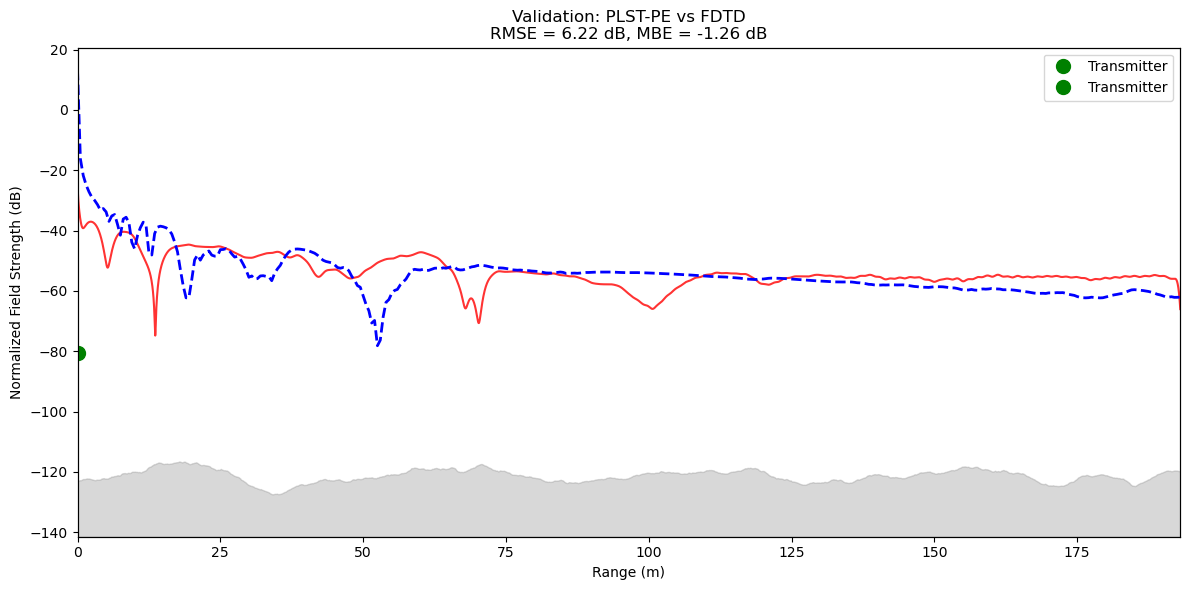

In [ ]:

# ==========================================
# 5. 主控制程序 (执行多条件扩展测试)
# ==========================================
if __name__ == "__main__":
    wind_speeds = [5.0, 10.0, 15.0]
    multi_ws_results = {}
    
    heatmap_data = None # 只保存一组数据用于画2D图 (例如 WS=10)

    for ws in wind_speeds:
        print(f"\n--- Running Simulation for Wind Speed = {ws} m/s ---")
        scene = SceneGenerator(wind_speed=ws)
        
        # 求解 FDTD
        fdtd_solver = FDTDSolver(scene)
        fdtd_range, fdtd_1d_mag, fdtd_2d_mag, z_coords_fdtd, tx_x_offset = fdtd_solver.run()
        
        # 提取 PE 输入海面
        tx_idx = np.argmin(np.abs(scene.x_full - tx_x_offset))
        pe_x_input = scene.x_full[tx_idx:] - scene.x_full[tx_idx]
        pe_h_input = scene.h_full[tx_idx:]
        
        # 求解 PE
        pe_solver = PESolver(scene)
        pe_solver.init_point_source(scene.tx_height, pe_h_input[0])
        pe_range, pe_1d_mag, pe_2d_mag, z_coords_pe = pe_solver.march(pe_x_input, pe_h_input, fdtd_range[-1], scene.rx_height)
        
        # 数据评估计算
        pe_dB, fdtd_dB_aligned, offset_dB = MetricsEvaluator.align_and_convert_to_dB(pe_1d_mag, fdtd_1d_mag, pe_range, fdtd_range)
        rmse = MetricsEvaluator.calc_rmse(pe_dB, fdtd_dB_aligned, pe_range, fdtd_range)
        
        # 暂存数据给后续制图
        multi_ws_results[ws] = (fdtd_range, fdtd_dB_aligned, pe_range, pe_dB, rmse)
        
        if ws == 10.0:
            heatmap_data = (fdtd_2d_mag, pe_2d_mag, fdtd_range, pe_range, z_coords_fdtd, z_coords_pe, offset_dB)

    # ============================
    # 统一调用 Visualizer 进行绘制
    # ============================
    print("\nGenerating Plots...")
    if heatmap_data:
        HeatmapVisualizer().plot(*heatmap_data)
        
    MultiWindSpeedVisualizer().plot(multi_ws_results)
    CumulativeRMSEVisualizer().plot(multi_ws_results)
    
    print("All simulations and plotting completed. Check PNG files.")